# Understanding Uncertainty Lab 4: Generating CDFs
## Fiona St. Clair

AI Disclosure: I used Claude AI to help draft and run the code for this lab, along with the in-class slides and my notes. The interpretation and reasoning in the written answers is my own.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, norm, expon

***
## Question 1

1. Set up a grid of $K$ equally spaced values between 0 and 1, `{1/K, 2/K, ..., K/K}`.
2. Draw a point from the grid at random with equal probability.
3. For a very small $K$, repeat the above process `n = 5_000` times, and plot the ECDF of the draws.
4. What distribution does this approach as you increase $K$?
    - As K increases, the grid points get closer together and the ECDF converges to the Uniform[0,1] CDF.

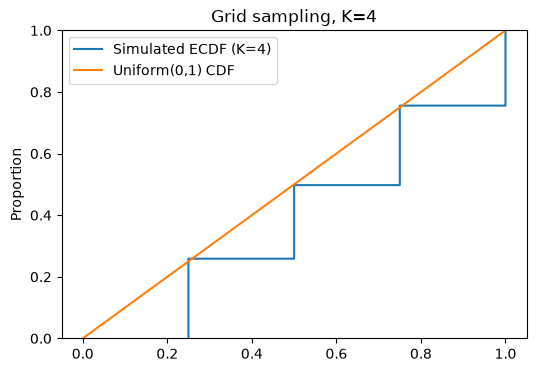

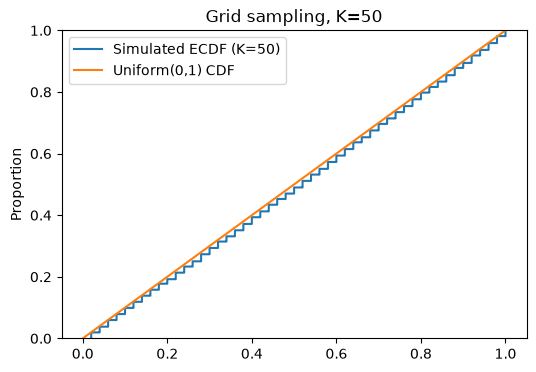

In [9]:
rng = np.random.default_rng(seed=100)

n = 5_000
x_grid = np.linspace(0, 1, 200)

for K in [4, 50]:
    grid = np.arange(1, K + 1) / K
    draws = rng.choice(grid, size=n)

    plt.figure(figsize=(6, 4))
    sns.ecdfplot(x=draws, label=f"Simulated ECDF (K={K})")
    plt.plot(x_grid, uniform.cdf(x_grid), label="Uniform(0,1) CDF")
    plt.title(f"Grid sampling, K={K}")
    plt.legend()
    plt.show()

***
## Question 2

1. Draw `n = 32` values from `Uniform[-sqrt(3), sqrt(3)]`; these are your data. The choice of $\pm \sqrt{3}$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by `np.sqrt(n)`.
3. Repeat the above process `b = 5_000` times and plot the ECDF.
4. What distribution does this approach as $n$ increases?
    - Sqrt(n) * X bar sub n converges to a normal distribution as n increases, regardless of the underlying uniform distribution of the data.

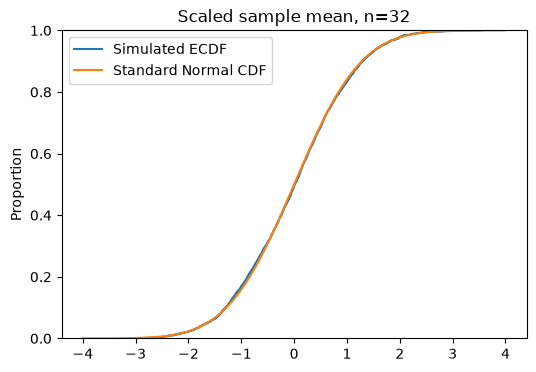

In [10]:
rng = np.random.default_rng(seed=100)

n = 32
b = 5_000
a = np.sqrt(3)

X = rng.uniform(-a, a, size=(b, n))
scaled_means = X.mean(axis=1) * np.sqrt(n)

x = np.linspace(-4, 4, 200)

plt.figure(figsize=(6, 4))
sns.ecdfplot(x=scaled_means, label="Simulated ECDF")
plt.plot(x, norm.cdf(x), label="Standard Normal CDF")
plt.title("Scaled sample mean, n=32")
plt.legend()
plt.show()

***
## Question 3

1. Flip `n = 40` coins, which each come up heads with probability $p = 1/2$ and tails with complementary probability.
2. From the final count of heads, subtract the expected number of heads, `n * p`.
3. Divide by the standard deviation `sqrt( n * p * (1-p) )`.
4. Repeat the above process `b = 5_000` times and plot the ECDF.
5. What distribution does this approach as $n$ increases?
    - As n increases, the standardized count converges to a Normal(0,1) distribution (similar to the previous question).
6. How do the results change as you adjust $p$?
    - For p=0.5, the approximation is already very close to normal at n=40, since the underlying distribution is symmetric. For extreme p (e.g. p=0.05), the distribution is highly skewed, so the standardized ECDF still shows visible skew relative to the normal curve at this sample size.

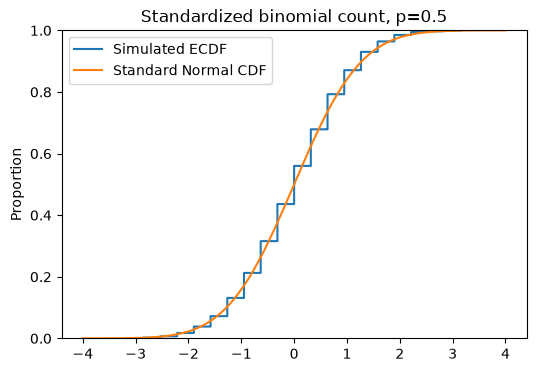

In [11]:
rng = np.random.default_rng(seed=100)

n = 40
p = 0.5
b = 5_000

heads = rng.binomial(n, p, size=b)
z = (heads - n * p) / np.sqrt(n * p * (1 - p))

x = np.linspace(-4, 4, 200)

plt.figure(figsize=(6, 4))
sns.ecdfplot(x=z, label="Simulated ECDF")
plt.plot(x, norm.cdf(x), label="Standard Normal CDF")
plt.title(f"Standardized binomial count, p={p}")
plt.legend()
plt.show()

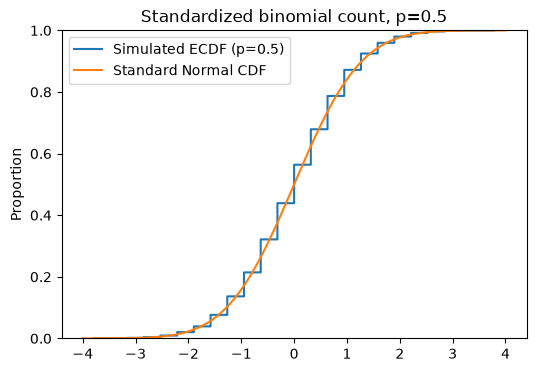

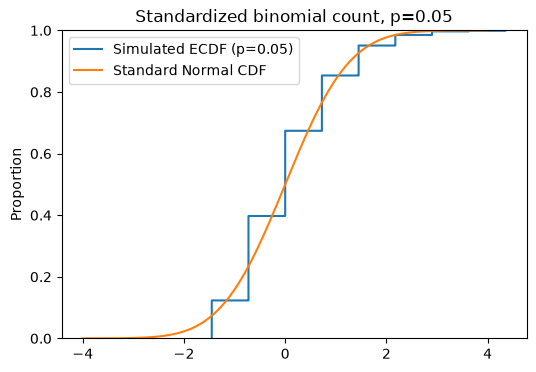

In [12]:
# How does the result change as p moves away from 0.5?
for p in [0.5, 0.05]:
    heads = rng.binomial(n, p, size=b)
    z = (heads - n * p) / np.sqrt(n * p * (1 - p))

    plt.figure(figsize=(6, 4))
    sns.ecdfplot(x=z, label=f"Simulated ECDF (p={p})")
    plt.plot(x, norm.cdf(x), label="Standard Normal CDF")
    plt.title(f"Standardized binomial count, p={p}")
    plt.legend()
    plt.show()

***
## Question 4

1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by `dt`.
3. Repeat the simulation `n = 5_000` times and plot the ECDF, for a value of `dt` close to zero (e.g. `dt = 1e-3`).
4. What distribution does this approach as $dt$ goes to zero?
    - As dt goes to zero, the discrete time termination process converges to a continuous Exponential(r) distribution. This is the discrete time analogue of the memoryless waiting-time process.
5. How do the results change as you adjust $r$?
    - Larger r means a higher termination probability per interval, so termination happens sooner on average, and the exponential distribution becomes more concentrated near 0 (mean 1/r shrinks as r grows).

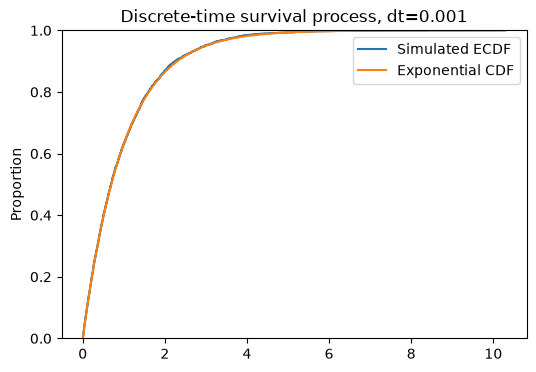

In [13]:
rng = np.random.default_rng(seed=100)

r = 1.0
dt = 1e-3
n = 5_000

p_term = r * dt
periods = rng.geometric(p_term, size=n)
time = periods * dt

x = np.linspace(0, 8, 200)

plt.figure(figsize=(6, 4))
sns.ecdfplot(x=time, label="Simulated ECDF")
plt.plot(x, expon.cdf(x, scale=1 / r), label="Exponential CDF")
plt.title(f"Discrete-time survival process, dt={dt}")
plt.legend()
plt.show()

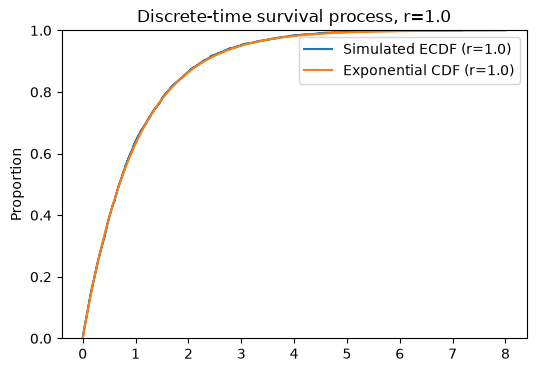

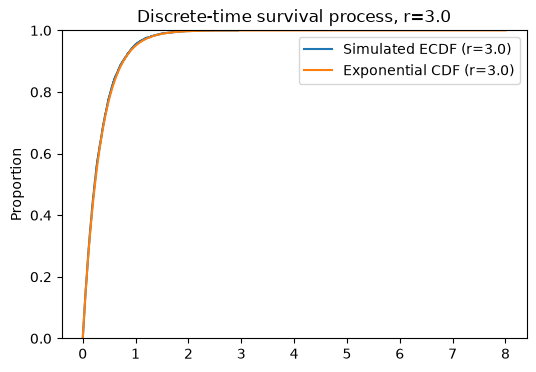

In [14]:
# how does the result change as r changes?
for r in [1.0, 3.0]:
    p_term = r * dt
    periods = rng.geometric(p_term, size=n)
    time = periods * dt

    plt.figure(figsize=(6, 4))
    sns.ecdfplot(x=time, label=f"Simulated ECDF (r={r})")
    plt.plot(x, expon.cdf(x, scale=1 / r), label=f"Exponential CDF (r={r})")
    plt.title(f"Discrete-time survival process, r={r}")
    plt.legend()
    plt.show()